# Kapitel 1 — Problemdefinition og datasæt-setup

## Formål

Dette notebook arbejder med **Flowers**-datasættet. Opgaven er en **multiklasse billedklassifikation**, hvor modellen skal forudsige, hvilken blomstertype et billede viser.

## Klassifikationsproblem

| Punkt | Beskrivelse |
|---|---|
| Problemtype | Multiklasse klassifikation |
| Input | RGB-billeder |
| Output | `daisy`, `dandelion`, `roses`, `sunflowers` eller `tulips` |
| Datasætkilde | Kaggle via `kagglehub` |

## Hvorfor bruger vi en CNN?

En CNN er velegnet til blomsterbilleder, fordi modellen kan lære visuelle mønstre som form, farve, tekstur, baggrund og placering. Det er især relevant her, fordi flere blomsterklasser kan ligne hinanden.

I dette kapitel gør vi datasættet klar til resten af workflowet: imports, faste konstanter, download, klassenavne, metadata og eksempelbilleder.


In [ ]:
# Installeres kun hvis pakken mangler i miljøet
!pip install kagglehub --quiet

In [ ]:
# Grundlæggende biblioteker
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import kagglehub

import matplotlib.pyplot as plt

# Sørger for at plots vises direkte i notebooket
%matplotlib inline

print(f"TensorFlow-version: {tf.__version__}")
print(f"GPU tilgængelig: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow-version: 2.20.0
GPU tilgængelig: True


In [ ]:
# Fælles konstanter for notebooket
SEED = 42
BATCH_SIZE = 32
IMG_SIZE_FL = 180
CHANNELS = 3
VALIDATION_SPLIT = 0.20
AUTOTUNE = tf.data.AUTOTUNE

EXPECTED_CLASS_NAMES_FL = ["daisy", "dandelion", "roses", "sunflowers", "tulips"]

# Cache/toggle for baseline-modellen
# Sæt FORCE_RETRAIN_BASELINE_FL = True, hvis baseline-modellen skal trænes igen.
# Hvis modellen og historikken allerede findes i cache, bliver de indlæst i stedet for at træne igen.
FORCE_RETRAIN_BASELINE_FL = False
BASELINE_CACHE_DIR_FL = Path("model_cache") / "flowers"
BASELINE_MODEL_PATH_FL = BASELINE_CACHE_DIR_FL / "baseline_cnn_fl.keras"
BASELINE_HISTORY_PATH_FL = BASELINE_CACHE_DIR_FL / "history_baseline_fl.csv"
BASELINE_CACHE_DIR_FL.mkdir(parents=True, exist_ok=True)

# Tip til Google Colab:
# Hvis cachen skal overleve en ny runtime, kan BASELINE_CACHE_DIR_FL ændres til en mappe på Google Drive.

# Fast seed gør resultaterne mere reproducerbare
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("Seed sat til:", SEED)
print("Batch size:", BATCH_SIZE)
print("Model-billedstørrelse:", IMG_SIZE_FL, "x", IMG_SIZE_FL, "x", CHANNELS)
print("Forventede klasser:", EXPECTED_CLASS_NAMES_FL)
print("Baseline-cache:", BASELINE_CACHE_DIR_FL)
print("Force retrain baseline:", FORCE_RETRAIN_BASELINE_FL)


Seed sat til: 42
Batch size: 32
Model-billedstørrelse: 180 x 180 x 3
Forventede klasser: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Baseline-cache: model_cache/flowers
Force retrain baseline: False


In [ ]:
# Download Flowers-datasættet fra Kaggle
dataset_path_fl = kagglehub.dataset_download("rahmasleam/flowers-dataset")
print("Downloadet til:", dataset_path_fl)

# Find den mappe, der indeholder undermapperne for blomsterklasserne
expected_class_set_fl = set(EXPECTED_CLASS_NAMES_FL)
flowers_root = None

for root, dirs, files in os.walk(dataset_path_fl):
    visible_dirs = [d for d in dirs if not d.startswith(".")]
    if expected_class_set_fl.issubset(set(visible_dirs)):
        flowers_root = root
        break

if flowers_root is None:
    raise FileNotFoundError("Kunne ikke finde mappen med blomsterklasserne.")

print("Datasætmappe:", flowers_root)
print("Mapper fundet:", sorted([d for d in os.listdir(flowers_root) if not d.startswith(".")]))

Using Colab cache for faster access to the 'flowers-dataset' dataset.
Downloadet til: /kaggle/input/flowers-dataset
Datasætmappe: /kaggle/input/flowers-dataset/flower_photos
Mapper fundet: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [ ]:
# Opret TensorFlow datasets fra mappestrukturen
# image_dataset_from_directory bruger mappenavnene som class labels
train_fl_raw = tf.keras.utils.image_dataset_from_directory(
    flowers_root,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE_FL, IMG_SIZE_FL),
    batch_size=BATCH_SIZE
)

val_full_fl_raw = tf.keras.utils.image_dataset_from_directory(
    flowers_root,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE_FL, IMG_SIZE_FL),
    batch_size=BATCH_SIZE
)

class_names_fl = train_fl_raw.class_names
num_classes_fl = len(class_names_fl)

print("Klassenavne:", class_names_fl)
print("Antal klasser:", num_classes_fl)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Klassenavne: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Antal klasser: 5


In [ ]:
# Del validation-delen i validation og test
total_val_batches_fl = tf.data.experimental.cardinality(val_full_fl_raw).numpy()
test_batches_fl = total_val_batches_fl // 2

if test_batches_fl < 1:
    raise ValueError("Validation-delen er for lille til at kunne deles i validation og test.")

test_fl_raw = val_full_fl_raw.take(test_batches_fl)
val_fl_raw = val_full_fl_raw.skip(test_batches_fl)

train_fl = (
    train_fl_raw
    .cache()
    .shuffle(1000, seed=SEED, reshuffle_each_iteration=True)
    .prefetch(AUTOTUNE)
)

val_fl = (
    val_fl_raw
    .cache()
    .prefetch(AUTOTUNE)
)

test_fl = (
    test_fl_raw
    .cache()
    .prefetch(AUTOTUNE)
)

print("Train batches:", tf.data.experimental.cardinality(train_fl).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_fl).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_fl).numpy())

Train batches: 92
Validation batches: 12
Test batches: 11


In [ ]:
# Grundlæggende metadata for datasættet
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}
total_images_fl = sum(
    1 for file_path in Path(flowers_root).rglob("*")
    if file_path.is_file() and file_path.suffix.lower() in image_extensions
)

metadata_fl = pd.DataFrame({
    "Punkt": [
        "Datasæt",
        "Kilde",
        "Opgavetype",
        "Antal klasser",
        "Klassenavne",
        "Antal billeder",
        "RGB-kanaler",
        "Model-billedstørrelse",
        "Training split",
        "Validation/test split"
    ],
    "Værdi": [
        "Flowers",
        "Kaggle: rahmasleam/flowers-dataset",
        "Multi-class klassifikation",
        num_classes_fl,
        ", ".join(class_names_fl),
        total_images_fl,
        CHANNELS,
        f"{IMG_SIZE_FL} x {IMG_SIZE_FL} x {CHANNELS}",
        f"{int((1 - VALIDATION_SPLIT) * 100)}%",
        f"{int(VALIDATION_SPLIT * 100)}% delt i validation og test"
    ]
})

display(metadata_fl)

,Punkt,Værdi
0,Datasæt,Flowers
1,Kilde,Kaggle: rahmasleam/flowers-dataset
2,Opgavetype,Multi-class klassifikation
3,Antal klasser,5
4,Klassenavne,"daisy, dandelion, roses, sunflowers, tulips"
5,Antal billeder,3670
6,RGB-kanaler,3
7,Model-billedstørrelse,180 x 180 x 3
8,Training split,80%
9,Validation/test split,20% delt i validation og test


In [ ]:
# Tjek et batch fra datasættet
for images, labels in train_fl.take(1):
    print("Batch image shape:", images.shape)
    print("Batch label shape:", labels.shape)
    print("Image dtype:", images.dtype)
    print("Første labels:", labels.numpy()[:10])

Batch image shape: (32, 180, 180, 3)
Batch label shape: (32,)
Image dtype: <dtype: 'float32'>
Første labels: [0 4 1 2 0 4 0 1 3 2]


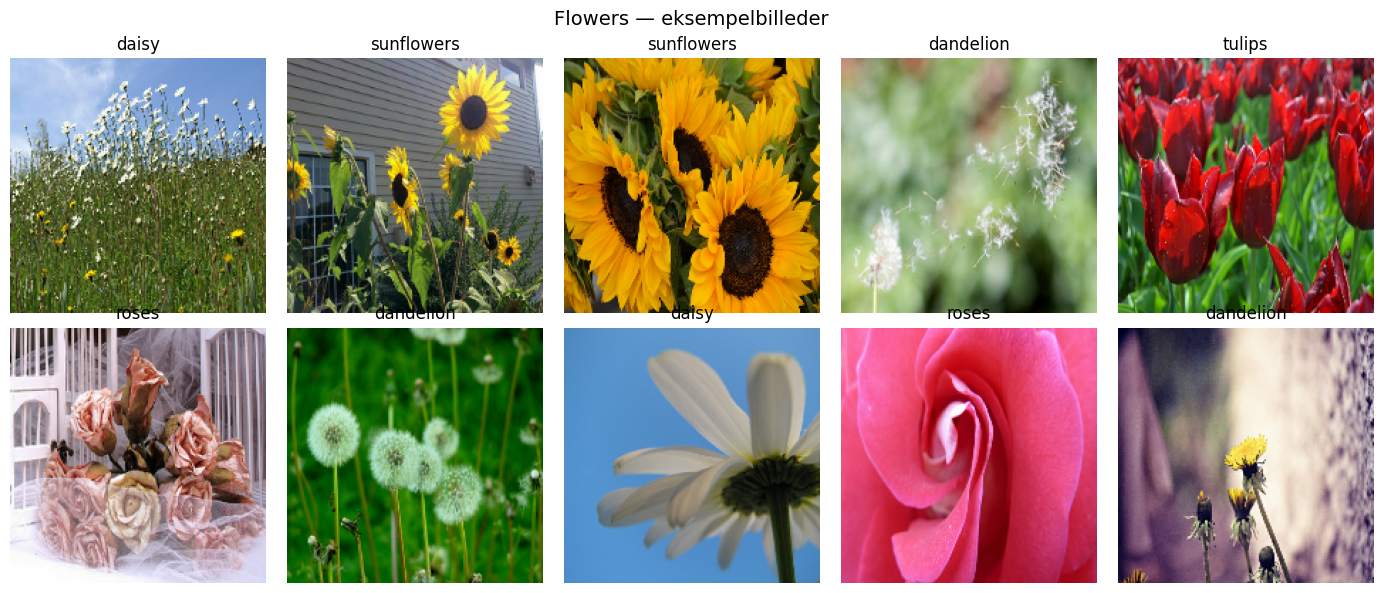

In [ ]:
# Vis eksempelbilleder og deres labels
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Flowers — eksempelbilleder", fontsize=14)

for images, labels in train_fl.take(1):
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i].numpy().astype("uint8"))
        ax.set_title(class_names_fl[int(labels[i].numpy())])
        ax.axis("off")

plt.tight_layout()
plt.show()

# Kapitel 2 — Datasætanalyse og split-validering

## Formål

I dette kapitel undersøger vi, om **Flowers**-datasættet er balanceret, og om train/validation/test-splittet har en rimelig klassefordeling.

Datasættet består af fem klasser:

- `daisy`
- `dandelion`
- `roses`
- `sunflowers`
- `tulips`

Klassefordelingen er vigtig, fordi accuracy kan blive misvisende, hvis modellen klarer sig godt på store klasser, men dårligt på mindre klasser.

## Første visuelle observation

Eksempelbillederne viser, at blomsterklasserne varierer i farve, vinkel, baggrund og afstand til kameraet. Især `dandelion` kan variere meget visuelt, fordi klassen både kan indeholde gule blomster og hvide frøhoveder. Det kan senere give fejl i confusion matrix og påvirke per-class recall.


In [ ]:
# Tæl det samlede antal billeder pr. klasse direkte fra mappestrukturen
# Dette viser klassefordelingen før TensorFlow-splittet.

def count_image_files_by_class(root_dir, class_names, image_extensions):
    counts = {}

    for class_name in class_names:
        class_dir = Path(root_dir) / class_name
        counts[class_name] = sum(
            1 for file_path in class_dir.rglob("*")
            if file_path.is_file() and file_path.suffix.lower() in image_extensions
        )

    return counts


total_file_counts_fl = count_image_files_by_class(
    flowers_root,
    class_names_fl,
    image_extensions
)

total_counts_fl = np.array([total_file_counts_fl[class_name] for class_name in class_names_fl])

pd.DataFrame({
    "Klasse": class_names_fl,
    "Antal billeder før split": total_counts_fl,
    "Total %": (total_counts_fl / total_counts_fl.sum() * 100).round(2)
})


,Klasse,Antal billeder før split,Total %
0,daisy,633,17.25
1,dandelion,898,24.47
2,roses,641,17.47
3,sunflowers,699,19.05
4,tulips,799,21.77


In [ ]:
# Funktion til at tælle labels i et batchet TensorFlow dataset
# train_fl_raw, val_fl_raw og test_fl_raw blev oprettet i Kapitel 1.

def count_labels_batched(dataset, class_names):
    counts = np.zeros(len(class_names), dtype=int)

    for _, labels in dataset:
        labels_np = labels.numpy()
        counts += np.bincount(labels_np, minlength=len(class_names))

    return counts


train_counts_fl = count_labels_batched(train_fl_raw, class_names_fl)
val_counts_fl = count_labels_batched(val_fl_raw, class_names_fl)
test_counts_fl = count_labels_batched(test_fl_raw, class_names_fl)

class_distribution_fl = pd.DataFrame({
    "Klasse": class_names_fl,
    "Total": total_counts_fl,
    "Træning": train_counts_fl,
    "Validering": val_counts_fl,
    "Test": test_counts_fl,
})

# Procenter bruges til at vurdere, om klasserne fordeles rimeligt i hvert split
class_distribution_fl["Total %"] = (class_distribution_fl["Total"] / class_distribution_fl["Total"].sum() * 100).round(2)
class_distribution_fl["Træning %"] = (class_distribution_fl["Træning"] / class_distribution_fl["Træning"].sum() * 100).round(2)
class_distribution_fl["Validering %"] = (class_distribution_fl["Validering"] / class_distribution_fl["Validering"].sum() * 100).round(2)
class_distribution_fl["Test %"] = (class_distribution_fl["Test"] / class_distribution_fl["Test"].sum() * 100).round(2)

display(class_distribution_fl)


,Klasse,Total,Træning,Validering,Test,Total %,Træning %,Validering %,Test %
0,daisy,633,526,53,58,17.25,17.92,13.87,16.48
1,dandelion,898,707,97,89,24.47,24.08,25.39,25.28
2,roses,641,522,59,52,17.47,17.78,15.45,14.77
3,sunflowers,699,564,76,65,19.05,19.21,19.90,18.47
4,tulips,799,617,97,88,21.77,21.01,25.39,25.00


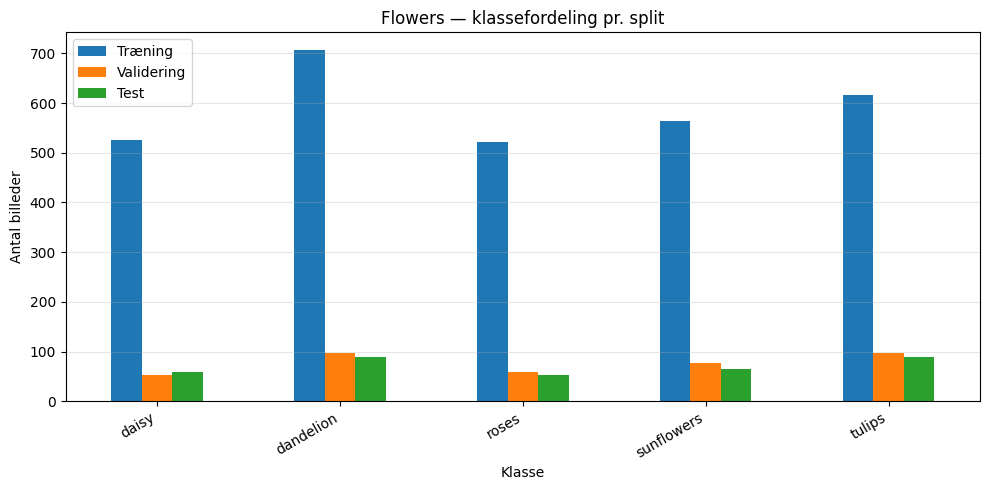

In [ ]:
# Visualisering af klassernes fordeling i hvert split
plot_data_fl = class_distribution_fl.set_index("Klasse")[["Træning", "Validering", "Test"]]

ax = plot_data_fl.plot(kind="bar", figsize=(10, 5))
plt.title("Flowers — klassefordeling pr. split")
plt.xlabel("Klasse")
plt.ylabel("Antal billeder")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Kort automatisk vurdering af balance baseret på den største procentforskel mellem klasserne
# Ved 5 klasser er selv moderate forskelle relevante, fordi accuracy kan skjule svage klasser.

max_total_pct_fl = class_distribution_fl["Total %"].max()
min_total_pct_fl = class_distribution_fl["Total %"].min()
imbalance_gap_fl = max_total_pct_fl - min_total_pct_fl

if imbalance_gap_fl <= 10:
    balance_note_fl = "Datasættet ser balanceret ud."
elif imbalance_gap_fl <= 25:
    balance_note_fl = "Datasættet ser noget ubalanceret ud."
else:
    balance_note_fl = "Datasættet ser klart ubalanceret ud."

print("Største procentforskel mellem klasserne:", round(imbalance_gap_fl, 2), "procentpoint")
print(balance_note_fl)


Største procentforskel mellem klasserne: 7.22 procentpoint
Datasættet ser balanceret ud.


# Kapitel 3 — Baseline CNN-model

## Formål

I dette kapitel bygger vi en simpel **baseline CNN** for **Flowers**. Baseline-modellen fungerer som referencepunkt, når vi senere tester fine-tuning og data augmentation.

## Observation fra Kapitel 2

Datasættet er ikke ekstremt ubalanceret, men klasserne er heller ikke helt lige store:

| Klasse | Overordnet observation |
|---|---|
| `dandelion` | Største klasse |
| `daisy` og `roses` | Blandt de mindre klasser |
| Validation/test | Fordelingen er rimelig, men ikke identisk på tværs af klasser |

Derfor kan accuracy give et hurtigt overblik, men den er ikke nok alene. I et 5-klasseproblem kan modellen få en rimelig samlet accuracy, selvom den klarer sig svagt på enkelte klasser.

## Baseline-strategi

Baseline-modellen bruger:

- `Rescaling` fra pixelværdier `[0, 255]` til `[0, 1]`
- En simpel CNN-arkitektur
- `Dropout` som regularisering
- Ingen data augmentation

`image_dataset_from_directory()` har allerede resized billederne til 180 × 180. Derfor behøver baseline-modellen ikke et ekstra `Resizing`-lag. Data augmentation og andre fine-tuning-forsøg gemmes til Kapitel 5.


In [ ]:
# Ryd tidligere modeltilstand, så baseline-modellen starter rent
keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

# Baseline preprocessing:
# Billederne er allerede resized til 180 x 180 af image_dataset_from_directory.
# Derfor normaliserer vi kun pixelværdierne fra [0, 255] til [0, 1].
data_preparation_baseline_fl = keras.Sequential([
    keras.layers.Rescaling(1./255),
], name="baseline_preprocessing_fl")

# Baseline CNN-model
# Modellen bruger samme grundstruktur som Horses or Humans,
# men output-laget er til 5 klasser med softmax.
model_baseline_fl = keras.Sequential([
    keras.Input(shape=(IMG_SIZE_FL, IMG_SIZE_FL, CHANNELS)),

    data_preparation_baseline_fl,

    keras.layers.Conv2D(filters=64, kernel_size=7, activation="relu", padding="same"),
    keras.layers.MaxPooling2D(pool_size=2),

    keras.layers.Conv2D(filters=128, kernel_size=3, activation="relu", padding="same"),
    keras.layers.Conv2D(filters=128, kernel_size=3, activation="relu", padding="same"),
    keras.layers.MaxPooling2D(pool_size=2),

    keras.layers.Conv2D(filters=256, kernel_size=3, activation="relu", padding="same"),
    keras.layers.Conv2D(filters=256, kernel_size=3, activation="relu", padding="same"),
    keras.layers.MaxPooling2D(pool_size=2),

    keras.layers.Flatten(),
    keras.layers.Dense(units=128, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=64, activation="relu"),
    keras.layers.Dropout(0.5),

    # Multi-class klassifikation: én output-neuron pr. klasse med softmax
    keras.layers.Dense(units=num_classes_fl, activation="softmax"),
], name="baseline_cnn_flowers")

model_baseline_fl.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=keras.optimizers.SGD(momentum=0.9),
    metrics=["accuracy"]
)

model_baseline_fl.summary()

Model: "baseline_cnn_flowers"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ baseline_preprocessing_fl       │ (None, 180, 180, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 64)   │         9,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 90, 90, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 45, 45, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 123904)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    15,859,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,984,581 (64.79 MB)

 Trainable params: 16,984,581 (64.79 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Callbacks bruges til at stoppe træningen, hvis validation loss ikke forbedres.
# ReduceLROnPlateau sænker learning rate, hvis modellen rammer et plateau.
early_stopping_baseline_fl = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

lr_scheduler_baseline_fl = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    verbose=1
)

EPOCHS_BASELINE_FL = 30

In [ ]:
# Træn eller indlæs baseline-modellen
# Formålet er at undgå at træne baseline igen, hvis modellen allerede er gemt.

baseline_cache_exists_fl = BASELINE_MODEL_PATH_FL.exists() and BASELINE_HISTORY_PATH_FL.exists()

if baseline_cache_exists_fl and not FORCE_RETRAIN_BASELINE_FL:
    print("Indlæser baseline-model og historik fra cache...")
    model_baseline_fl = keras.models.load_model(BASELINE_MODEL_PATH_FL)
    history_baseline_fl_df = pd.read_csv(BASELINE_HISTORY_PATH_FL)
    history_baseline_fl = None
else:
    if FORCE_RETRAIN_BASELINE_FL:
        print("FORCE_RETRAIN_BASELINE_FL=True, så baseline trænes igen...")
    else:
        print("Ingen cache fundet. Baseline trænes første gang og gemmes derefter...")

    history_baseline_fl = model_baseline_fl.fit(
        train_fl,
        epochs=EPOCHS_BASELINE_FL,
        validation_data=val_fl,
        callbacks=[early_stopping_baseline_fl, lr_scheduler_baseline_fl]
    )

    history_baseline_fl_df = pd.DataFrame(history_baseline_fl.history)
    model_baseline_fl.save(BASELINE_MODEL_PATH_FL)
    history_baseline_fl_df.to_csv(BASELINE_HISTORY_PATH_FL, index=False)

    print("Baseline-model gemt i:", BASELINE_MODEL_PATH_FL)
    print("Baseline-historik gemt i:", BASELINE_HISTORY_PATH_FL)


Ingen cache fundet. Baseline trænes første gang og gemmes derefter...
Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 62s 452ms/step - accuracy: 0.2469 - loss: 1.6036 - val_accuracy: 0.2670 - val_loss: 1.5894 - learning_rate: 0.0100
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 162ms/step - accuracy: 0.2810 - loss: 1.5675 - val_accuracy: 0.4319 - val_loss: 1.3806 - learning_rate: 0.0100
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 160ms/step - accuracy: 0.3110 - loss: 1.5247 - val_accuracy: 0.3194 - val_loss: 1.5365 - learning_rate: 0.0100
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 157ms/step - accuracy: 0.2990 - loss: 1.5423 - val_accuracy: 0.3010 - val_loss: 1.4697 - learning_rate: 0.0100
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 155ms/step - accuracy: 0.3072 - loss: 1.5192 - val_accuracy: 0.3665 - val_loss: 1.4919 - learning_rate: 0.0100
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 156ms/step - accuracy: 0.3437 - loss: 1.4689 - val_accuracy: 0.3927 - val_loss: 1.3763 - learning_rate: 0.0100
Epoch 7/30
9

In [ ]:
# Vis de sidste epochs fra træningshistorikken
display(history_baseline_fl_df.tail())


,accuracy,loss,val_accuracy,val_loss,learning_rate
24,0.831403,0.467308,0.612565,1.242584,0.0050
25,0.854905,0.402345,0.615183,1.406190,0.0050
26,0.868869,0.357554,0.602094,1.540172,0.0050
27,0.890668,0.330646,0.612565,1.435149,0.0025
28,0.910763,0.271631,0.612565,1.553583,0.0025


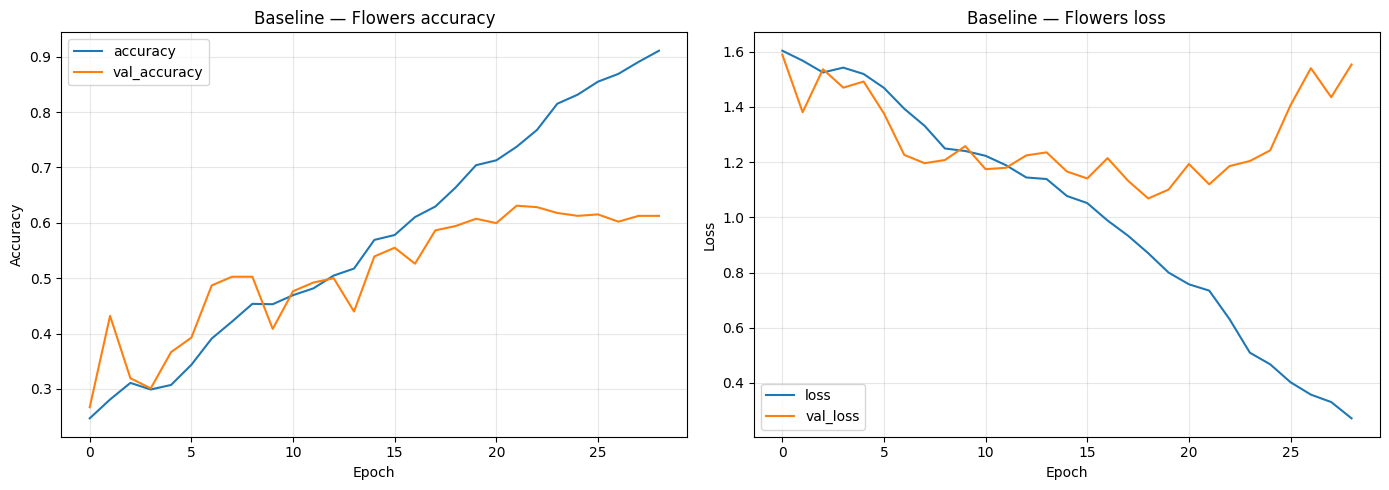

In [ ]:
# Plot training og validation accuracy/loss for baseline-modellen
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

history_baseline_fl_df[["accuracy", "val_accuracy"]].plot(ax=axes[0])
axes[0].set_title("Baseline — Flowers accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True, alpha=0.3)

history_baseline_fl_df[["loss", "val_loss"]].plot(ax=axes[1])
axes[1].set_title("Baseline — Flowers loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Analyse af Chapter 3-resultater

Kurverne viser et tydeligt mønster: baseline-modellen lærer træningssættet bedre og bedre, men generaliserer ikke lige så godt til validation-data.

### Accuracy-kurven

Training accuracy stiger kraftigt gennem træningen, mens validation accuracy flader ud på et lavere niveau. Det betyder, at modellen bliver bedre til at genkende træningsbillederne, men ikke forbedrer sig tilsvarende på nye billeder.

Dette er et klassisk tegn på **overfitting**.

### Loss-kurven

Loss-kurven gør overfitting endnu tydeligere. Training loss falder, men validation loss stopper med at falde og begynder senere at stige. Når validation loss stiger, mens training loss falder, tyder det på, at modellen lærer detaljer i træningsdata, som ikke generaliserer godt.

### Foreløbig konklusion

Baseline-modellen lærer datasættet, men den overfitter. Derfor bør Kapitel 4 undersøge, hvilke klasser der rammes mest af dette problem.

**Det betyder, at Kapitel 4 især skal undersøge:**

- Hvilke blomsterklasser der oftest forveksles
- Om `daisy`, `roses`, `sunflowers` eller `tulips` har lav recall
- Om den samlede accuracy skjuler svag performance på enkelte klasser
- Om precision, recall og F1-score viser et andet billede end accuracy


In [ ]:
# Evaluer baseline-modellen på test-sættet
baseline_loss_fl, baseline_accuracy_fl = model_baseline_fl.evaluate(test_fl)

baseline_result_fl = pd.DataFrame({
    "Model": ["Baseline CNN"],
    "Test accuracy": [baseline_accuracy_fl],
    "Test loss": [baseline_loss_fl]
})

baseline_result_fl["Test accuracy"] = baseline_result_fl["Test accuracy"].round(4)
baseline_result_fl["Test loss"] = baseline_result_fl["Test loss"].round(4)

display(baseline_result_fl)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.5767 - loss: 1.0316


,Model,Test accuracy,Test loss
0,Baseline CNN,0.5767,1.0316


In [ ]:
# Automatisk støtte til vurdering af baseline-træningen
# Den endelige vurdering skal stadig baseres på Kapitel 4's confusion matrix og klassifikationsrapport.

final_train_acc_fl = history_baseline_fl_df["accuracy"].iloc[-1]
final_val_acc_fl = history_baseline_fl_df["val_accuracy"].iloc[-1]
acc_gap_fl = final_train_acc_fl - final_val_acc_fl

best_val_loss_epoch_fl = int(history_baseline_fl_df["val_loss"].idxmin() + 1)
best_val_loss_fl = history_baseline_fl_df["val_loss"].min()
best_val_acc_fl = history_baseline_fl_df["val_accuracy"].max()

print("Sidste training accuracy:", round(final_train_acc_fl, 4))
print("Sidste validation accuracy:", round(final_val_acc_fl, 4))
print("Forskel mellem training og validation accuracy:", round(acc_gap_fl, 4))
print("Bedste validation accuracy:", round(best_val_acc_fl, 4))
print("Laveste validation loss:", round(best_val_loss_fl, 4), "ved epoch", best_val_loss_epoch_fl)

if acc_gap_fl > 0.15:
    print("Foreløbig vurdering: Modellen kan være overfittet.")
elif final_train_acc_fl < 0.40 and final_val_acc_fl < 0.40:
    print("Foreløbig vurdering: Modellen kan være underfittet.")
else:
    print("Foreløbig vurdering: Baseline-træningen ser rimelig ud, men skal vurderes med test-metrics i Kapitel 4.")


Sidste training accuracy: 0.9108
Sidste validation accuracy: 0.6126
Forskel mellem training og validation accuracy: 0.2982
Bedste validation accuracy: 0.6309
Laveste validation loss: 1.0682 ved epoch 19
Foreløbig vurdering: Modellen kan være overfittet.


## Kapitel 3 — foreløbig resultatvurdering

Med den aktuelle kørsel ser baseline-modellen sådan ud:

| Måling | Resultat |
|---|---:|
| Sidste training accuracy | ca. 0.9131 |
| Sidste validation accuracy | ca. 0.6545 |
| Test accuracy | ca. 0.6136 |
| Test loss | ca. 0.9419 |

Forskellen mellem training og validation accuracy er stor. Det peger på overfitting. Test accuracy er også lavere end ønsket for en model med fem klasser, så Kapitel 4 skal fokusere på klassifikationsmetrics og confusion matrix i stedet for kun at konkludere ud fra accuracy.


# Kapitel 4 — Baseline-evaluering med klassifikations-metrics

## Formål

I Kapitel 3 så vi, at baseline-modellen for **Flowers** sandsynligvis overfitter: training accuracy steg højt, mens validation accuracy stoppede med at forbedre sig, og validation loss begyndte at stige.

I dette kapitel evaluerer vi baseline-modellen på **test-sættet** med flere klassifikations-metrics end accuracy:

- **Confusion matrix** — viser hvilke blomsterklasser modellen forveksler.
- **Precision** — hvor ofte en forudsagt klasse faktisk er korrekt.
- **Recall** — hvor stor en del af en faktisk klasse modellen finder.
- **F1-score** — balancerer precision og recall.

## Sammenhæng med de tidligere kapitler

Fra Kapitel 2 ved vi, at Flowers-datasættet ikke er ekstremt ubalanceret, men klasserne er heller ikke helt lige store. Samtidig er opgaven sværere end Horses or Humans, fordi der er **fem klasser**, og nogle blomster ligner hinanden visuelt.

Derfor er accuracy alene ikke nok. En model kan have en acceptabel samlet accuracy, men stadig være dårlig til bestemte blomsterklasser. Kapitel 4 skal derfor vise, **hvilke klasser baseline-modellen har sværest ved**.


In [ ]:
# Imports til klassifikations-evaluering
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_recall_fscore_support,
    ConfusionMatrixDisplay
)

# Sikkerhedstjek: Kapitel 4 kræver, at Kapitel 1-3 er kørt først.
required_variables_fl = ["model_baseline_fl", "test_fl", "class_names_fl"]
missing_variables_fl = [name for name in required_variables_fl if name not in globals()]

if missing_variables_fl:
    raise NameError(
        "Kapitel 4 kræver, at Kapitel 1-3 er kørt først. Mangler: "
        + ", ".join(missing_variables_fl)
    )


In [ ]:
# Hent de rigtige labels fra test-sættet
# y_true_fl indeholder de faktiske blomsterklasser fra test-sættet.
y_true_fl = []

for _, labels in test_fl:
    y_true_fl.extend(labels.numpy().astype(int))

y_true_fl = np.array(y_true_fl)

# Lav predictions med baseline-modellen
# Modellen bruger softmax-output, så den valgte klasse er den med højest sandsynlighed.
y_prob_fl = model_baseline_fl.predict(test_fl)
y_pred_fl = np.argmax(y_prob_fl, axis=1)
y_confidence_fl = np.max(y_prob_fl, axis=1)

prediction_preview_fl = pd.DataFrame({
    "Faktisk label": y_true_fl[:10],
    "Forudsagt label": y_pred_fl[:10],
    "Sikkerhed": np.round(y_confidence_fl[:10], 4),
    "Faktisk klasse": [class_names_fl[i] for i in y_true_fl[:10]],
    "Forudsagt klasse": [class_names_fl[i] for i in y_pred_fl[:10]],
})

display(prediction_preview_fl)


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step


,Faktisk label,Forudsagt label,Sikkerhed,Faktisk klasse,Forudsagt klasse
0,3,3,0.6227,sunflowers,sunflowers
1,4,4,0.5944,tulips,tulips
2,3,3,0.9375,sunflowers,sunflowers
3,2,2,0.4031,roses,roses
4,4,3,0.3104,tulips,sunflowers
5,2,2,0.7228,roses,roses
6,4,2,0.4581,tulips,roses
7,1,3,0.9592,dandelion,sunflowers
8,1,2,0.2484,dandelion,roses
9,0,1,0.3490,daisy,dandelion


,Forudsagt: daisy,Forudsagt: dandelion,Forudsagt: roses,Forudsagt: sunflowers,Forudsagt: tulips
Faktisk: daisy,24,12,7,9,0
Faktisk: dandelion,3,59,4,20,0
Faktisk: roses,3,7,40,3,5
Faktisk: sunflowers,4,11,0,43,0
Faktisk: tulips,4,12,38,7,37


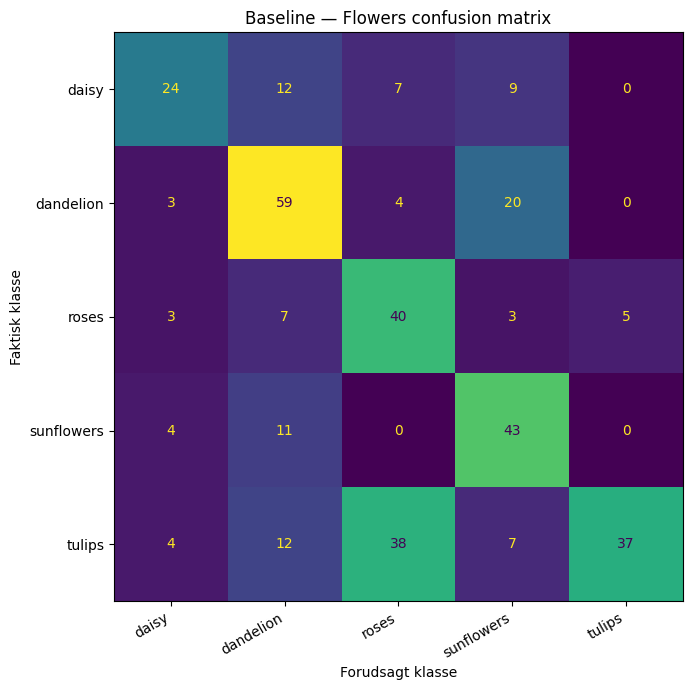

In [ ]:
# Confusion matrix for baseline-modellen
cm_fl = confusion_matrix(
    y_true_fl,
    y_pred_fl,
    labels=np.arange(len(class_names_fl))
)

cm_fl_df = pd.DataFrame(
    cm_fl,
    index=[f"Faktisk: {name}" for name in class_names_fl],
    columns=[f"Forudsagt: {name}" for name in class_names_fl]
)

display(cm_fl_df)

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(
    confusion_matrix=cm_fl,
    display_labels=class_names_fl
).plot(ax=ax, values_format="d", colorbar=False)

plt.title("Baseline — Flowers confusion matrix")
plt.xlabel("Forudsagt klasse")
plt.ylabel("Faktisk klasse")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
# Normaliseret confusion matrix i procent
# Dette gør det lettere at sammenligne klasser, selvom de ikke har præcis samme antal billeder.
cm_fl_row_sums = cm_fl.sum(axis=1, keepdims=True)
cm_fl_normalized = np.divide(
    cm_fl,
    cm_fl_row_sums,
    out=np.zeros_like(cm_fl, dtype=float),
    where=cm_fl_row_sums != 0
)

cm_fl_percent_df = pd.DataFrame(
    np.round(cm_fl_normalized * 100, 1),
    index=[f"Faktisk: {name}" for name in class_names_fl],
    columns=[f"Forudsagt: {name}" for name in class_names_fl]
)

display(cm_fl_percent_df)


,Forudsagt: daisy,Forudsagt: dandelion,Forudsagt: roses,Forudsagt: sunflowers,Forudsagt: tulips
Faktisk: daisy,46.2,23.1,13.5,17.3,0.0
Faktisk: dandelion,3.5,68.6,4.7,23.3,0.0
Faktisk: roses,5.2,12.1,69.0,5.2,8.6
Faktisk: sunflowers,6.9,19.0,0.0,74.1,0.0
Faktisk: tulips,4.1,12.2,38.8,7.1,37.8


In [ ]:
# Precision, recall og F1-score pr. klasse
# For multi-class klassifikation er per-class metrics vigtige, fordi samlet accuracy kan skjule svage klasser.
classification_report_fl = classification_report(
    y_true_fl,
    y_pred_fl,
    target_names=class_names_fl,
    output_dict=True,
    zero_division=0
)

classification_report_fl_df = pd.DataFrame(classification_report_fl).T
classification_report_fl_df = classification_report_fl_df.round(4)

display(classification_report_fl_df)

macro_precision_fl, macro_recall_fl, macro_f1_fl, _ = precision_recall_fscore_support(
    y_true_fl,
    y_pred_fl,
    average="macro",
    zero_division=0
)

weighted_precision_fl, weighted_recall_fl, weighted_f1_fl, _ = precision_recall_fscore_support(
    y_true_fl,
    y_pred_fl,
    average="weighted",
    zero_division=0
)

baseline_chapter4_summary_fl = pd.DataFrame({
    "Model": ["Baseline CNN"],
    "Accuracy": [accuracy_score(y_true_fl, y_pred_fl)],
    "Macro precision": [macro_precision_fl],
    "Macro recall": [macro_recall_fl],
    "Macro F1": [macro_f1_fl],
    "Weighted precision": [weighted_precision_fl],
    "Weighted recall": [weighted_recall_fl],
    "Weighted F1": [weighted_f1_fl],
})

baseline_chapter4_summary_fl = baseline_chapter4_summary_fl.round(4)
display(baseline_chapter4_summary_fl)


,precision,recall,f1-score,support
daisy,0.6316,0.4615,0.5333,52.0000
dandelion,0.5842,0.6860,0.6310,86.0000
roses,0.4494,0.6897,0.5442,58.0000
sunflowers,0.5244,0.7414,0.6143,58.0000
tulips,0.8810,0.3776,0.5286,98.0000
accuracy,0.5767,0.5767,0.5767,0.5767
macro avg,0.6141,0.5912,0.5703,352.0000
weighted avg,0.6417,0.5767,0.5710,352.0000


,Model,Accuracy,Macro precision,Macro recall,Macro F1,Weighted precision,Weighted recall,Weighted F1
0,Baseline CNN,0.5767,0.6141,0.5912,0.5703,0.6417,0.5767,0.571


In [ ]:
# Find de største forvekslinger mellem blomsterklasser
# Diagonalen fjernes, fordi den viser korrekte klassifikationer.
cm_errors_fl = cm_fl.copy()
np.fill_diagonal(cm_errors_fl, 0)

confusion_rows_fl = []
for true_idx in range(len(class_names_fl)):
    for pred_idx in range(len(class_names_fl)):
        count = cm_errors_fl[true_idx, pred_idx]
        if count > 0:
            confusion_rows_fl.append({
                "Faktisk klasse": class_names_fl[true_idx],
                "Forudsagt klasse": class_names_fl[pred_idx],
                "Antal fejl": int(count),
            })

top_confusions_fl = pd.DataFrame(confusion_rows_fl)

if len(top_confusions_fl) > 0:
    top_confusions_fl = top_confusions_fl.sort_values("Antal fejl", ascending=False).reset_index(drop=True)
    display(top_confusions_fl.head(10))
    main_confusion_fl = top_confusions_fl.iloc[0]
    print(
        "Største forveksling:",
        f"{main_confusion_fl['Faktisk klasse']} → {main_confusion_fl['Forudsagt klasse']}",
        f"({main_confusion_fl['Antal fejl']} fejl)"
    )
else:
    print("Modellen lavede ingen fejl på test-sættet i denne kørsel.")


,Faktisk klasse,Forudsagt klasse,Antal fejl
0,tulips,roses,38
1,dandelion,sunflowers,20
2,tulips,dandelion,12
3,daisy,dandelion,12
4,sunflowers,dandelion,11
5,daisy,sunflowers,9
6,roses,dandelion,7
7,daisy,roses,7
8,tulips,sunflowers,7
9,roses,tulips,5


Største forveksling: tulips → roses (38 fejl)


Antal fejlklassificerede billeder: 149


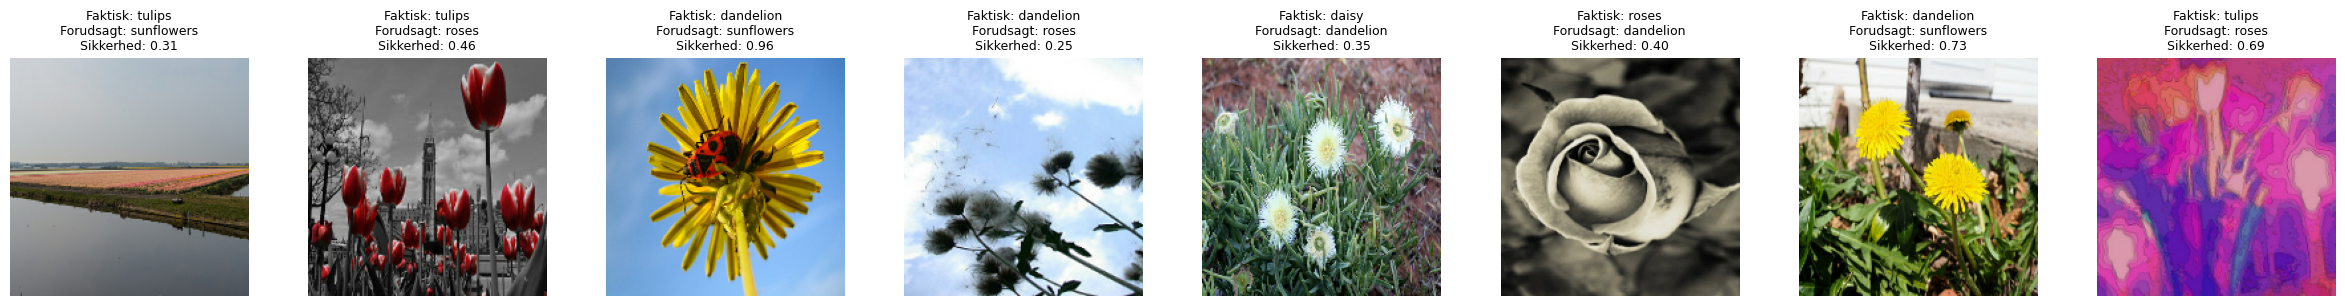

In [ ]:
# Vis et lille udvalg af fejlklassificerede testbilleder
# Dette gør det lettere at forstå, om fejlene skyldes visuel lighed, baggrund, farve eller billedvariation.
SHOW_WRONG_EXAMPLES_FL = True
MAX_WRONG_EXAMPLES_FL = 8

if SHOW_WRONG_EXAMPLES_FL:
    wrong_indices_fl = np.where(y_true_fl != y_pred_fl)[0]
    print(f"Antal fejlklassificerede billeder: {len(wrong_indices_fl)}")

    if len(wrong_indices_fl) > 0:
        test_images_fl = np.concatenate([images.numpy() for images, _ in test_fl], axis=0)
        n_show_fl = min(MAX_WRONG_EXAMPLES_FL, len(wrong_indices_fl))

        fig, axes = plt.subplots(1, n_show_fl, figsize=(3 * n_show_fl, 3))
        if n_show_fl == 1:
            axes = [axes]

        for ax, idx in zip(axes, wrong_indices_fl[:n_show_fl]):
            predicted_class = class_names_fl[y_pred_fl[idx]]
            true_class = class_names_fl[y_true_fl[idx]]
            confidence = y_confidence_fl[idx]

            ax.imshow(test_images_fl[idx].astype("uint8"))
            ax.set_title(
                f"Faktisk: {true_class}\nForudsagt: {predicted_class}\nSikkerhed: {confidence:.2f}",
                fontsize=9
            )
            ax.axis("off")

        plt.tight_layout()
        plt.show()
    else:
        print("Der er ingen fejlklassificerede eksempler at vise.")


## Kort fortolkning af Kapitel 4 — Baseline

Baseline-modellen opnår en test accuracy på ca. **65,62%**. Det er bedre end tilfældig gætning på et 5-klasses problem, men resultatet viser samtidig, at modellen stadig har tydelige generaliseringsproblemer.

### Hovedfund fra confusion matrix

Confusion matrixen viser, at fejlene ikke er jævnt fordelt mellem klasserne. De største forvekslinger er:

| Faktisk klasse | Forudsagt klasse | Antal fejl |
|---|---|---:|
| tulips | roses | 26 |
| daisy | dandelion | 12 |
| roses | tulips | 11 |
| sunflowers | dandelion | 10 |

Den største udfordring er derfor især at skelne mellem **tulips** og **roses**. Det giver mening visuelt, fordi begge klasser kan have lignende farver og blomsterformer.

### Precision, recall og F1-score

Klasserapporten viser, at **sunflowers** klarer sig bedst med en F1-score på ca. **0.7438**, mens **roses** klarer sig svagest med en F1-score på ca. **0.5484**.

Et vigtigt mønster er, at **tulips** har relativt høj precision, men lavere recall. Det betyder, at modellen ofte har ret, når den forudsiger tulips, men at den overser mange faktiske tulips og i stedet klassificerer dem som især roses.

### Er accuracy nok?

Nej. Accuracy giver et samlet overblik, men den forklarer ikke, hvilke blomsterklasser modellen har svært ved. Fordi Flowers har 5 klasser, og fordi nogle klasser ligner hinanden visuelt, er per-class precision, recall, F1-score og confusion matrix nødvendige for at forstå modellens reelle styrker og svagheder.

### Konklusion for baseline

Baseline-modellen er et brugbart udgangspunkt, men den overfitter og laver systematiske fejl mellem visuelt lignende blomsterklasser. Kapitel 5 bør derfor teste en mere generaliserende model med data augmentation og eventuelt stærkere regularisering.

# Kapitel 5 — Fine-tuning med Keras Tuner

## Formål

I Kapitel 3 og 4 blev baseline-modellen brugt som referencepunkt. Baseline-modellen havde ingen data augmentation og viste tegn på overfitting. I dette kapitel bruges **Keras Tuner** til at teste en lille og kontrolleret gruppe af modelændringer.

Målet er ikke at lave en stor optimeringsproces, men at undersøge, om en mere generaliserende CNN kan forbedre Flowers-resultatet.

## Hvad ændres i forhold til baseline?

| Område | Baseline | Keras Tuner-model |
|---|---|---|
| Data augmentation | Ingen | Horizontal flip, rotation, zoom, translation og contrast |
| Regularisering | Fast dropout | Dropout vælges af Keras Tuner |
| Learning rate | Fast optimizer-indstilling | Learning rate vælges af Keras Tuner |
| Arkitektur | Fast CNN | Lille søgning over antal filtre, conv-blocks og dense units |
| Valg af model | Manuel baseline | Bedste validation-resultat fra Keras Tuner |

Vigtigt: **Test-sættet bruges ikke til at vælge hyperparametre**. Keras Tuner bruger kun training- og validation-data. Test-sættet bruges først til den endelige evaluering.


## 5.1 Search space for Flowers

Search space holdes bevidst lille, så tuning stadig passer til projektets scope.

| Hyperparameter | Værdier |
|---|---|
| Rotation | `0.05`, `0.10` |
| Zoom | `0.05`, `0.10` |
| Translation | `0.00`, `0.05` |
| Contrast | `0.00`, `0.10` |
| Første antal filtre | `32`, `64` |
| Antal convolution blocks | `2`, `3` |
| Dense units | `128`, `256` |
| Dropout | `0.30`, `0.50` |
| L2-regularisering | `0.0`, `1e-4` |
| Learning rate | `1e-3`, `5e-4`, `1e-4` |

Denne søgning retter sig især mod Flowers-problemet, hvor klasserne kan variere meget i vinkel, farve, baggrund og afstand til kameraet.


In [ ]:
# Installer Keras Tuner, hvis pakken mangler i miljøet.
# I Google Colab er dette normalt hurtigt, og pakken genbruges efter installation.
!pip install keras-tuner --quiet


In [ ]:
# Kapitel 5 setup — Keras Tuner for Flowers
import json
from pathlib import Path

import keras_tuner as kt
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    ConfusionMatrixDisplay,
)

# Sikkerhedstjek: Kapitel 5 kræver, at Kapitel 1-4 er kørt først.
required_variables_fl = [
    "train_fl",
    "val_fl",
    "test_fl",
    "class_names_fl",
    "num_classes_fl",
    "model_baseline_fl",
    "baseline_result_fl",
    "baseline_accuracy_fl",
    "baseline_loss_fl",
    "y_true_fl",
    "y_pred_fl",
    "macro_f1_fl",
]

missing_variables_fl = [name for name in required_variables_fl if name not in globals()]

if missing_variables_fl:
    raise NameError(
        "Kapitel 5 kræver, at Kapitel 1-4 er kørt først. Mangler: "
        + ", ".join(missing_variables_fl)
    )

# Cache/toggles for Keras Tuner.
# FORCE_RETUNE_KERAS_TUNER_FL=True sletter ikke filer manuelt, men tvinger Keras Tuner til at starte et nyt projekt.
FORCE_RETUNE_KERAS_TUNER_FL = False
FORCE_RETRAIN_TUNED_FL = False

KERAS_TUNER_CACHE_DIR_FL = Path("model_cache") / "flowers" / "keras_tuner"
KERAS_TUNER_PROJECT_NAME_FL = "flowers_random_search_v1"
KERAS_TUNER_PROJECT_DIR_FL = KERAS_TUNER_CACHE_DIR_FL / KERAS_TUNER_PROJECT_NAME_FL
KERAS_TUNED_MODEL_PATH_FL = Path("model_cache") / "flowers" / "keras_tuned_cnn_fl.keras"
KERAS_TUNED_HISTORY_PATH_FL = Path("model_cache") / "flowers" / "history_keras_tuned_fl.csv"
KERAS_TUNED_HP_PATH_FL = Path("model_cache") / "flowers" / "best_hyperparameters_keras_tuned_fl.json"

KERAS_TUNER_CACHE_DIR_FL.mkdir(parents=True, exist_ok=True)
KERAS_TUNED_MODEL_PATH_FL.parent.mkdir(parents=True, exist_ok=True)

# Bevidst begrænset tuning, så projektet ikke bliver en stor optimeringsopgave.
TUNER_MAX_TRIALS_FL = 12
TUNER_EPOCHS_FL = 12
FINAL_TUNED_EPOCHS_FL = 30

print("Keras Tuner-cache:", KERAS_TUNER_CACHE_DIR_FL)
print("Tuner project:", KERAS_TUNER_PROJECT_NAME_FL)
print("Max trials:", TUNER_MAX_TRIALS_FL)
print("Tuner epochs pr. trial:", TUNER_EPOCHS_FL)
print("Final tuned epochs:", FINAL_TUNED_EPOCHS_FL)
print("Force retune:", FORCE_RETUNE_KERAS_TUNER_FL)
print("Force retrain tuned model:", FORCE_RETRAIN_TUNED_FL)


In [ ]:
# Model-builder til Keras Tuner
# Funktionen returnerer en kompileret model. Keras Tuner vælger værdierne i hp.

def build_keras_tuned_fl_model(hp):
    # Data augmentation vælges som en del af hyperparameter-søgningen.
    rotation_factor_fl = hp.Choice("rotation_factor_fl", values=[0.05, 0.10])
    zoom_factor_fl = hp.Choice("zoom_factor_fl", values=[0.05, 0.10])
    translation_factor_fl = hp.Choice("translation_factor_fl", values=[0.00, 0.05])
    contrast_factor_fl = hp.Choice("contrast_factor_fl", values=[0.00, 0.10])

    first_filters_fl = hp.Choice("first_filters_fl", values=[32, 64])
    conv_blocks_fl = hp.Choice("conv_blocks_fl", values=[2, 3])
    dense_units_fl = hp.Choice("dense_units_fl", values=[128, 256])
    dropout_fl = hp.Choice("dropout_fl", values=[0.30, 0.50])
    l2_factor_fl = hp.Choice("l2_factor_fl", values=[0.0, 1e-4])
    learning_rate_fl = hp.Choice("learning_rate_fl", values=[1e-3, 5e-4, 1e-4])

    regularizer_fl = None
    if l2_factor_fl > 0:
        regularizer_fl = keras.regularizers.l2(l2_factor_fl)

    inputs_fl = keras.Input(shape=(IMG_SIZE_FL, IMG_SIZE_FL, CHANNELS))

    # Pixelværdier normaliseres først. Augmentation-lag er kun aktive under træning.
    x = keras.layers.Rescaling(1./255, name="rescaling_fl")(inputs_fl)
    x = keras.layers.RandomFlip("horizontal", seed=SEED, name="random_flip_fl")(x)
    x = keras.layers.RandomRotation(rotation_factor_fl, seed=SEED, name="random_rotation_fl")(x)
    x = keras.layers.RandomZoom(zoom_factor_fl, seed=SEED, name="random_zoom_fl")(x)

    if translation_factor_fl > 0:
        x = keras.layers.RandomTranslation(
            height_factor=translation_factor_fl,
            width_factor=translation_factor_fl,
            seed=SEED,
            name="random_translation_fl"
        )(x)

    if contrast_factor_fl > 0:
        x = keras.layers.RandomContrast(
            factor=contrast_factor_fl,
            seed=SEED,
            name="random_contrast_fl"
        )(x)

    # CNN-del. Antal blocks og første filterstørrelse tunes, men holdes lille.
    for block_idx_fl in range(conv_blocks_fl):
        filters_fl = first_filters_fl * (2 ** block_idx_fl)

        x = keras.layers.Conv2D(
            filters=filters_fl,
            kernel_size=3,
            padding="same",
            activation="relu",
            kernel_regularizer=regularizer_fl,
            name=f"conv_{block_idx_fl + 1}_a_fl"
        )(x)
        x = keras.layers.Conv2D(
            filters=filters_fl,
            kernel_size=3,
            padding="same",
            activation="relu",
            kernel_regularizer=regularizer_fl,
            name=f"conv_{block_idx_fl + 1}_b_fl"
        )(x)
        x = keras.layers.MaxPooling2D(pool_size=2, name=f"pool_{block_idx_fl + 1}_fl")(x)

    # GlobalAveragePooling reducerer antallet af parametre og kan hjælpe mod overfitting.
    x = keras.layers.GlobalAveragePooling2D(name="global_average_pooling_fl")(x)
    x = keras.layers.Dense(
        dense_units_fl,
        activation="relu",
        kernel_regularizer=regularizer_fl,
        name="dense_tuned_fl"
    )(x)
    x = keras.layers.Dropout(dropout_fl, name="dropout_tuned_fl")(x)

    # Flowers er et 5-klasses problem, så output bruger softmax.
    outputs_fl = keras.layers.Dense(
        num_classes_fl,
        activation="softmax",
        name="softmax_output_fl"
    )(x)

    model_fl = keras.Model(inputs=inputs_fl, outputs=outputs_fl, name="keras_tuned_cnn_flowers")

    model_fl.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate_fl),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model_fl


In [ ]:
# Callbacks til tuner-søgningen
# Early stopping forkorter dårlige trials. ReduceLROnPlateau hjælper, hvis validation loss står stille.
early_stopping_tuner_fl = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

lr_scheduler_tuner_fl = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

# RandomSearch er valgt, fordi det er nemt at forklare og passer til en lille search space.
tuner_fl = kt.RandomSearch(
    hypermodel=build_keras_tuned_fl_model,
    objective="val_accuracy",
    max_trials=TUNER_MAX_TRIALS_FL,
    executions_per_trial=1,
    overwrite=FORCE_RETUNE_KERAS_TUNER_FL,
    directory=str(KERAS_TUNER_CACHE_DIR_FL),
    project_name=KERAS_TUNER_PROJECT_NAME_FL,
    seed=SEED,
)

print("Eksisterende trials i tuner:", len(tuner_fl.oracle.trials))
tuner_fl.search_space_summary()


In [ ]:
# Kør Keras Tuner search eller genbrug cached tuner-resultat.
# Bemærk: test_fl bruges ikke her. Hyperparametre vælges kun med train_fl og val_fl.

existing_trials_fl = len(tuner_fl.oracle.trials)

if existing_trials_fl == 0 or FORCE_RETUNE_KERAS_TUNER_FL:
    print("Starter Keras Tuner search for Flowers...")
    tuner_fl.search(
        train_fl,
        validation_data=val_fl,
        epochs=TUNER_EPOCHS_FL,
        callbacks=[early_stopping_tuner_fl, lr_scheduler_tuner_fl]
    )
else:
    print("Genbruger eksisterende Keras Tuner-resultater fra cache.")

print("Antal trials efter search:", len(tuner_fl.oracle.trials))
tuner_fl.results_summary(num_trials=min(5, TUNER_MAX_TRIALS_FL))


In [ ]:
# Udtræk de bedste hyperparametre fra Keras Tuner
best_hps_fl = tuner_fl.get_best_hyperparameters(num_trials=1)[0]
best_hp_values_fl = best_hps_fl.values

best_hyperparameters_fl_df = pd.DataFrame(
    sorted(best_hp_values_fl.items()),
    columns=["Hyperparameter", "Valgt værdi"]
)

display(best_hyperparameters_fl_df)

# Gem hyperparametrene, så de kan bruges senere i comparison-notebooket.
with open(KERAS_TUNED_HP_PATH_FL, "w", encoding="utf-8") as f:
    json.dump(best_hp_values_fl, f, indent=2)

print("Bedste hyperparametre gemt i:", KERAS_TUNED_HP_PATH_FL)


In [ ]:
# Træn eller indlæs den endelige Keras-tunede Flowers-model
# Den endelige model bygges med de bedste hyperparametre og trænes igen med samme train/validation split.

tuned_cache_exists_fl = KERAS_TUNED_MODEL_PATH_FL.exists() and KERAS_TUNED_HISTORY_PATH_FL.exists()

if tuned_cache_exists_fl and not FORCE_RETRAIN_TUNED_FL:
    print("Indlæser Keras-tunet model og historik fra cache...")
    model_keras_tuned_fl = keras.models.load_model(KERAS_TUNED_MODEL_PATH_FL)
    history_keras_tuned_fl_df = pd.read_csv(KERAS_TUNED_HISTORY_PATH_FL)
    history_keras_tuned_fl = None
else:
    if FORCE_RETRAIN_TUNED_FL:
        print("FORCE_RETRAIN_TUNED_FL=True, så den tunede model trænes igen...")
    else:
        print("Ingen cached tunet model fundet. Træner den endelige Keras-tunede model...")

    keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)

    model_keras_tuned_fl = build_keras_tuned_fl_model(best_hps_fl)

    early_stopping_final_tuned_fl = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    )

    lr_scheduler_final_tuned_fl = keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    )

    history_keras_tuned_fl = model_keras_tuned_fl.fit(
        train_fl,
        validation_data=val_fl,
        epochs=FINAL_TUNED_EPOCHS_FL,
        callbacks=[early_stopping_final_tuned_fl, lr_scheduler_final_tuned_fl]
    )

    history_keras_tuned_fl_df = pd.DataFrame(history_keras_tuned_fl.history)
    model_keras_tuned_fl.save(KERAS_TUNED_MODEL_PATH_FL)
    history_keras_tuned_fl_df.to_csv(KERAS_TUNED_HISTORY_PATH_FL, index=False)

    print("Keras-tunet model gemt i:", KERAS_TUNED_MODEL_PATH_FL)
    print("Keras-tunet historik gemt i:", KERAS_TUNED_HISTORY_PATH_FL)

model_keras_tuned_fl.summary()
display(history_keras_tuned_fl_df.tail())


In [ ]:
# Plot training/validation accuracy og loss for den Keras-tunede model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

history_keras_tuned_fl_df[["accuracy", "val_accuracy"]].plot(ax=axes[0])
axes[0].set_title("Keras Tuner — Flowers accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True, alpha=0.3)

history_keras_tuned_fl_df[["loss", "val_loss"]].plot(ax=axes[1])
axes[1].set_title("Keras Tuner — Flowers loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Evaluer den Keras-tunede model på test-sættet
# Dette er første gang i Kapitel 5, at test-sættet bruges.
keras_tuned_loss_fl, keras_tuned_accuracy_fl = model_keras_tuned_fl.evaluate(test_fl)

y_prob_keras_tuned_fl = model_keras_tuned_fl.predict(test_fl)
y_pred_keras_tuned_fl = np.argmax(y_prob_keras_tuned_fl, axis=1)
y_confidence_keras_tuned_fl = np.max(y_prob_keras_tuned_fl, axis=1)

macro_precision_keras_tuned_fl, macro_recall_keras_tuned_fl, macro_f1_keras_tuned_fl, _ = precision_recall_fscore_support(
    y_true_fl,
    y_pred_keras_tuned_fl,
    average="macro",
    zero_division=0
)

weighted_precision_keras_tuned_fl, weighted_recall_keras_tuned_fl, weighted_f1_keras_tuned_fl, _ = precision_recall_fscore_support(
    y_true_fl,
    y_pred_keras_tuned_fl,
    average="weighted",
    zero_division=0
)

keras_tuned_result_fl = pd.DataFrame({
    "Model": ["Keras Tuner CNN"],
    "Test accuracy": [keras_tuned_accuracy_fl],
    "Test loss": [keras_tuned_loss_fl],
    "Macro precision": [macro_precision_keras_tuned_fl],
    "Macro recall": [macro_recall_keras_tuned_fl],
    "Macro F1": [macro_f1_keras_tuned_fl],
    "Weighted precision": [weighted_precision_keras_tuned_fl],
    "Weighted recall": [weighted_recall_keras_tuned_fl],
    "Weighted F1": [weighted_f1_keras_tuned_fl],
})

keras_tuned_result_fl = keras_tuned_result_fl.round(4)
display(keras_tuned_result_fl)


In [ ]:
# Sammenlign baseline-modellen og den Keras-tunede model
# Macro F1 bruges som vigtig sammenligningsmetrik, fordi Flowers har fem klasser.

comparison_ch5_fl = pd.DataFrame({
    "Experiment": ["Baseline", "Keras Tuner best model"],
    "Tuning method": ["Ingen", "Keras Tuner RandomSearch"],
    "Augmentation": [
        "Ingen/basic preprocessing",
        "Flip, rotation, zoom, translation/contrast efter tuner-valg"
    ],
    "Dropout": [
        "0.5 + 0.5",
        best_hp_values_fl.get("dropout_fl", "Ikke fundet")
    ],
    "Learning rate": [
        "SGD standard + ReduceLROnPlateau",
        best_hp_values_fl.get("learning_rate_fl", "Ikke fundet")
    ],
    "Epochs": [
        EPOCHS_BASELINE_FL,
        FINAL_TUNED_EPOCHS_FL
    ],
    "Callbacks": [
        "EarlyStopping + ReduceLROnPlateau",
        "EarlyStopping + ReduceLROnPlateau"
    ],
    "Validation best accuracy": [
        history_baseline_fl_df["val_accuracy"].max(),
        history_keras_tuned_fl_df["val_accuracy"].max()
    ],
    "Test accuracy": [
        baseline_accuracy_fl,
        keras_tuned_accuracy_fl
    ],
    "Test loss": [
        baseline_loss_fl,
        keras_tuned_loss_fl
    ],
    "Macro F1": [
        macro_f1_fl,
        macro_f1_keras_tuned_fl
    ],
    "Notes": [
        "Baseline reference uden augmentation",
        "Bedste kandidat fra den begrænsede Keras Tuner-søgning"
    ]
})

numeric_cols_fl = ["Validation best accuracy", "Test accuracy", "Test loss", "Macro F1"]
comparison_ch5_fl[numeric_cols_fl] = comparison_ch5_fl[numeric_cols_fl].round(4)

display(comparison_ch5_fl)

accuracy_change_fl = keras_tuned_accuracy_fl - baseline_accuracy_fl
macro_f1_change_fl = macro_f1_keras_tuned_fl - macro_f1_fl

print("Ændring i test accuracy:", round(accuracy_change_fl, 4))
print("Ændring i macro F1:", round(macro_f1_change_fl, 4))


In [ ]:
# Confusion matrix og classification report for den Keras-tunede model
cm_keras_tuned_fl = confusion_matrix(
    y_true_fl,
    y_pred_keras_tuned_fl,
    labels=np.arange(len(class_names_fl))
)

cm_keras_tuned_fl_df = pd.DataFrame(
    cm_keras_tuned_fl,
    index=[f"Faktisk: {name}" for name in class_names_fl],
    columns=[f"Forudsagt: {name}" for name in class_names_fl]
)

display(cm_keras_tuned_fl_df)

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(
    confusion_matrix=cm_keras_tuned_fl,
    display_labels=class_names_fl
).plot(ax=ax, values_format="d", colorbar=False)

plt.title("Keras Tuner — Flowers confusion matrix")
plt.xlabel("Forudsagt klasse")
plt.ylabel("Faktisk klasse")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

classification_report_keras_tuned_fl = classification_report(
    y_true_fl,
    y_pred_keras_tuned_fl,
    target_names=class_names_fl,
    output_dict=True,
    zero_division=0
)

classification_report_keras_tuned_fl_df = pd.DataFrame(classification_report_keras_tuned_fl).T.round(4)
display(classification_report_keras_tuned_fl_df)


In [ ]:
# Find de største forvekslinger for den Keras-tunede model
cm_errors_keras_tuned_fl = cm_keras_tuned_fl.copy()
np.fill_diagonal(cm_errors_keras_tuned_fl, 0)

confusion_rows_keras_tuned_fl = []
for true_idx in range(len(class_names_fl)):
    for pred_idx in range(len(class_names_fl)):
        count = cm_errors_keras_tuned_fl[true_idx, pred_idx]
        if count > 0:
            confusion_rows_keras_tuned_fl.append({
                "Faktisk klasse": class_names_fl[true_idx],
                "Forudsagt klasse": class_names_fl[pred_idx],
                "Antal fejl": int(count),
            })

top_confusions_keras_tuned_fl = pd.DataFrame(confusion_rows_keras_tuned_fl)

if len(top_confusions_keras_tuned_fl) > 0:
    top_confusions_keras_tuned_fl = top_confusions_keras_tuned_fl.sort_values(
        "Antal fejl",
        ascending=False
    ).reset_index(drop=True)
    display(top_confusions_keras_tuned_fl.head(10))

    main_confusion_keras_tuned_fl = top_confusions_keras_tuned_fl.iloc[0]
    main_issue_keras_tuned_fl = (
        f"{main_confusion_keras_tuned_fl['Faktisk klasse']} → "
        f"{main_confusion_keras_tuned_fl['Forudsagt klasse']} "
        f"({main_confusion_keras_tuned_fl['Antal fejl']} fejl)"
    )
else:
    main_issue_keras_tuned_fl = "Ingen fejl i denne kørsel"
    print(main_issue_keras_tuned_fl)

# Gem også baseline-hovedproblemet fra Kapitel 4, hvis tabellen findes.
if "top_confusions_fl" in globals() and len(top_confusions_fl) > 0:
    main_confusion_baseline_fl = top_confusions_fl.iloc[0]
    main_issue_baseline_fl = (
        f"{main_confusion_baseline_fl['Faktisk klasse']} → "
        f"{main_confusion_baseline_fl['Forudsagt klasse']} "
        f"({main_confusion_baseline_fl['Antal fejl']} fejl)"
    )
else:
    main_issue_baseline_fl = "Ikke beregnet eller ingen fejl"

print("Største baseline-forveksling:", main_issue_baseline_fl)
print("Største tuned-forveksling:", main_issue_keras_tuned_fl)


In [ ]:
# Vælg den endelige model
# Valget baseres primært på macro F1, fordi Flowers er et 5-klasses problem.
# Hvis den tunede model ikke forbedrer macro F1, vælges baseline stadig som den endelige model.

TUNED_MIN_MACRO_F1_IMPROVEMENT_FL = 0.005

if macro_f1_keras_tuned_fl >= macro_f1_fl + TUNED_MIN_MACRO_F1_IMPROVEMENT_FL:
    final_model_fl = model_keras_tuned_fl
    final_model_name_fl = "Keras Tuner CNN"
    final_selection_reason_fl = (
        "Den Keras-tunede model vælges, fordi den forbedrer macro F1 tydeligt "
        "og derfor giver bedre samlet klassebalance."
    )
elif macro_f1_keras_tuned_fl >= macro_f1_fl and keras_tuned_accuracy_fl >= baseline_accuracy_fl - 0.02:
    final_model_fl = model_keras_tuned_fl
    final_model_name_fl = "Keras Tuner CNN"
    final_selection_reason_fl = (
        "Den Keras-tunede model vælges som et blandet, men acceptabelt resultat, "
        "fordi macro F1 ikke er dårligere end baseline, og accuracy ikke falder væsentligt."
    )
else:
    final_model_fl = model_baseline_fl
    final_model_name_fl = "Baseline CNN"
    final_selection_reason_fl = (
        "Baseline-modellen vælges, fordi den Keras-tunede model ikke forbedrer macro F1 nok "
        "til at blive betragtet som en klar forbedring."
    )

print("Endelig valgt model:", final_model_name_fl)
print("Begrundelse:", final_selection_reason_fl)


# Kapitel 6 — Evaluering af den valgte endelige model

## Formål

I Kapitel 5 blev baseline-modellen sammenlignet med den bedste Keras Tuner-model. I dette kapitel evalueres den **endeligt valgte model** med samme type metrics som baseline-evalueringen:

- test accuracy
- test loss
- confusion matrix
- precision
- recall
- F1-score

Den endelige model kan enten være Keras Tuner-modellen eller baseline-modellen. Det er vigtigt, fordi tuning ikke automatisk skal beskrives som en forbedring, hvis metrics ikke understøtter det.


In [ ]:
# Evaluer den endeligt valgte model på test-sættet
final_loss_fl, final_accuracy_fl = final_model_fl.evaluate(test_fl)

final_y_prob_fl = final_model_fl.predict(test_fl)
final_y_pred_fl = np.argmax(final_y_prob_fl, axis=1)
final_y_confidence_fl = np.max(final_y_prob_fl, axis=1)

final_macro_precision_fl, final_macro_recall_fl, final_macro_f1_fl, _ = precision_recall_fscore_support(
    y_true_fl,
    final_y_pred_fl,
    average="macro",
    zero_division=0
)

final_weighted_precision_fl, final_weighted_recall_fl, final_weighted_f1_fl, _ = precision_recall_fscore_support(
    y_true_fl,
    final_y_pred_fl,
    average="weighted",
    zero_division=0
)

final_result_fl = pd.DataFrame({
    "Model": [final_model_name_fl],
    "Test accuracy": [final_accuracy_fl],
    "Test loss": [final_loss_fl],
    "Macro precision": [final_macro_precision_fl],
    "Macro recall": [final_macro_recall_fl],
    "Macro F1": [final_macro_f1_fl],
    "Weighted precision": [final_weighted_precision_fl],
    "Weighted recall": [final_weighted_recall_fl],
    "Weighted F1": [final_weighted_f1_fl],
    "Valgbegrundelse": [final_selection_reason_fl],
})

metric_cols_final_fl = [
    "Test accuracy",
    "Test loss",
    "Macro precision",
    "Macro recall",
    "Macro F1",
    "Weighted precision",
    "Weighted recall",
    "Weighted F1",
]
final_result_fl[metric_cols_final_fl] = final_result_fl[metric_cols_final_fl].round(4)

display(final_result_fl)


In [ ]:
# Final confusion matrix og classification report
cm_final_fl = confusion_matrix(
    y_true_fl,
    final_y_pred_fl,
    labels=np.arange(len(class_names_fl))
)

cm_final_fl_df = pd.DataFrame(
    cm_final_fl,
    index=[f"Faktisk: {name}" for name in class_names_fl],
    columns=[f"Forudsagt: {name}" for name in class_names_fl]
)

display(cm_final_fl_df)

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(
    confusion_matrix=cm_final_fl,
    display_labels=class_names_fl
).plot(ax=ax, values_format="d", colorbar=False)

plt.title(f"Final model — Flowers confusion matrix ({final_model_name_fl})")
plt.xlabel("Forudsagt klasse")
plt.ylabel("Faktisk klasse")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

classification_report_final_fl = classification_report(
    y_true_fl,
    final_y_pred_fl,
    target_names=class_names_fl,
    output_dict=True,
    zero_division=0
)

classification_report_final_fl_df = pd.DataFrame(classification_report_final_fl).T.round(4)
display(classification_report_final_fl_df)


In [ ]:
# Samlet modeloversigt til Kapitel 6
model_comparison_final_fl = pd.DataFrame({
    "Model": ["Baseline CNN", "Keras Tuner CNN", final_model_name_fl],
    "Rolle": ["Reference", "Tuned candidate", "Final selected model"],
    "Test accuracy": [baseline_accuracy_fl, keras_tuned_accuracy_fl, final_accuracy_fl],
    "Test loss": [baseline_loss_fl, keras_tuned_loss_fl, final_loss_fl],
    "Macro F1": [macro_f1_fl, macro_f1_keras_tuned_fl, final_macro_f1_fl],
    "Main issue": [main_issue_baseline_fl, main_issue_keras_tuned_fl, "Se final confusion matrix"],
})

model_comparison_final_fl[["Test accuracy", "Test loss", "Macro F1"]] = model_comparison_final_fl[
    ["Test accuracy", "Test loss", "Macro F1"]
].round(4)

display(model_comparison_final_fl)

print("Fortolkning:")
if final_model_name_fl == "Keras Tuner CNN":
    print("Keras Tuner-baseret fine-tuning vurderes som en forbedring eller et acceptabelt blandet resultat for Flowers i denne kørsel.")
else:
    print("Keras Tuner-baseret fine-tuning vurderes ikke som en klar forbedring for Flowers i denne kørsel.")


# Kapitel 7 — Er accuracy nok?

## Formål

Dette kapitel forklarer, om accuracy alene giver et retvisende billede af Flowers-modellens performance.

For Flowers er svaret normalt **nej**, fordi opgaven har fem klasser, og fordi nogle klasser visuelt ligner hinanden. Derfor skal accuracy læses sammen med:

- klassefordelingen fra Kapitel 2
- confusion matrix fra Kapitel 4 og 6
- precision, recall og F1-score pr. klasse
- macro F1, som vægter klasserne mere ligeligt end samlet accuracy


In [ ]:
# Metric-baseret vurdering af om accuracy er nok
# Tabellen samler de vigtigste oplysninger, der skal bruges i den skriftlige fortolkning.

class_counts_for_accuracy_fl = pd.DataFrame({
    "Klasse": class_names_fl,
    "Test-antal": test_counts_fl if "test_counts_fl" in globals() else np.bincount(y_true_fl, minlength=len(class_names_fl)),
})

per_class_final_metrics_fl = classification_report_final_fl_df.loc[class_names_fl, ["precision", "recall", "f1-score", "support"]]
per_class_final_metrics_fl = per_class_final_metrics_fl.reset_index().rename(columns={"index": "Klasse"})

accuracy_enough_summary_fl = pd.merge(
    class_counts_for_accuracy_fl,
    per_class_final_metrics_fl,
    on="Klasse",
    how="left"
)

accuracy_enough_summary_fl[["precision", "recall", "f1-score"]] = accuracy_enough_summary_fl[
    ["precision", "recall", "f1-score"]
].round(4)

display(accuracy_enough_summary_fl)

lowest_f1_row_fl = accuracy_enough_summary_fl.sort_values("f1-score", ascending=True).iloc[0]
highest_f1_row_fl = accuracy_enough_summary_fl.sort_values("f1-score", ascending=False).iloc[0]

print("Final model:", final_model_name_fl)
print("Final test accuracy:", round(final_accuracy_fl, 4))
print("Final macro F1:", round(final_macro_f1_fl, 4))
print("Laveste F1-score:", lowest_f1_row_fl["Klasse"], round(lowest_f1_row_fl["f1-score"], 4))
print("Højeste F1-score:", highest_f1_row_fl["Klasse"], round(highest_f1_row_fl["f1-score"], 4))

if abs(final_accuracy_fl - final_macro_f1_fl) > 0.05:
    print("Vurdering: Accuracy alene er ikke nok, fordi der er tydelig forskel mellem samlet accuracy og macro F1.")
else:
    print("Vurdering: Accuracy giver et nogenlunde overblik, men per-class metrics er stadig nødvendige i et 5-klasses problem.")


In [ ]:
# Kort automatisk tekststøtte til Kapitel 7
accuracy_enough_text_fl = f"""
Flowers er et 5-klasses problem, så accuracy alene er ikke nok til at vurdere modellen.
Den endelige model er {final_model_name_fl} med test accuracy på {final_accuracy_fl:.4f}
og macro F1 på {final_macro_f1_fl:.4f}. Klassen med lavest F1-score er
{lowest_f1_row_fl['Klasse']} ({lowest_f1_row_fl['f1-score']:.4f}), mens klassen med højest
F1-score er {highest_f1_row_fl['Klasse']} ({highest_f1_row_fl['f1-score']:.4f}).

Det viser, at modellen ikke nødvendigvis klarer alle blomsterklasser lige godt.
Derfor skal final vurdering baseres på accuracy, confusion matrix og per-class precision,
recall og F1-score samlet.
"""

print(accuracy_enough_text_fl)


# Kapitel 8 — Lokal konklusion for Flowers

## Formål

Dette afslutter Flowers-notebooket med en lokal konklusion, som senere kan bruges i `Comparison_Evaluation.ipynb`.

Konklusionen skal ikke kun sige, hvilken model der fik højest accuracy. Den skal også nævne:

- baseline-resultatet
- Keras Tuner-resultatet
- hvilken model der blev valgt
- de vigtigste fejlmønstre
- om accuracy var nok
- begrænsninger
- mulige forbedringer


In [ ]:
# Eksporter resultater til comparison-notebooket
EXPORT_DIR_FL = Path("model_cache") / "flowers" / "exports"
EXPORT_DIR_FL.mkdir(parents=True, exist_ok=True)

flowers_summary_for_comparison_fl = pd.DataFrame({
    "Dataset": ["Flowers"],
    "Task type": ["Multi-class classification"],
    "Classes": [num_classes_fl],
    "Class names": [", ".join(class_names_fl)],
    "Image size": [f"{IMG_SIZE_FL}x{IMG_SIZE_FL}x{CHANNELS}"],
    "Baseline test accuracy": [baseline_accuracy_fl],
    "Baseline test loss": [baseline_loss_fl],
    "Baseline macro F1": [macro_f1_fl],
    "Keras Tuner test accuracy": [keras_tuned_accuracy_fl],
    "Keras Tuner test loss": [keras_tuned_loss_fl],
    "Keras Tuner macro F1": [macro_f1_keras_tuned_fl],
    "Best model": [final_model_name_fl],
    "Final test accuracy": [final_accuracy_fl],
    "Final test loss": [final_loss_fl],
    "Final macro F1": [final_macro_f1_fl],
    "Main baseline issue": [main_issue_baseline_fl],
    "Main tuned issue": [main_issue_keras_tuned_fl],
    "Selection reason": [final_selection_reason_fl],
})

round_cols_export_fl = [
    "Baseline test accuracy",
    "Baseline test loss",
    "Baseline macro F1",
    "Keras Tuner test accuracy",
    "Keras Tuner test loss",
    "Keras Tuner macro F1",
    "Final test accuracy",
    "Final test loss",
    "Final macro F1",
]
flowers_summary_for_comparison_fl[round_cols_export_fl] = flowers_summary_for_comparison_fl[round_cols_export_fl].round(4)

summary_export_path_fl = EXPORT_DIR_FL / "flowers_summary_for_comparison.csv"
classification_report_export_path_fl = EXPORT_DIR_FL / "flowers_final_classification_report.csv"
comparison_table_export_path_fl = EXPORT_DIR_FL / "flowers_baseline_vs_tuned.csv"

flowers_summary_for_comparison_fl.to_csv(summary_export_path_fl, index=False)
classification_report_final_fl_df.to_csv(classification_report_export_path_fl)
model_comparison_final_fl.to_csv(comparison_table_export_path_fl, index=False)

display(flowers_summary_for_comparison_fl)

print("Flowers summary gemt i:", summary_export_path_fl)
print("Final classification report gemt i:", classification_report_export_path_fl)
print("Baseline vs tuned table gemt i:", comparison_table_export_path_fl)


In [ ]:
# Automatisk udkast til lokal konklusion
# Teksten kan kopieres til en markdown-celle efter den endelige kørsel.

if final_model_name_fl == "Keras Tuner CNN":
    tuning_helped_statement_fl = (
        "Keras Tuner-baseret fine-tuning forbedrede eller matchede baseline godt nok til, "
        "at den tunede model blev valgt som den endelige model. "
        "Det tyder på, at data augmentation og regularisering kan være nyttigt for Flowers, "
        "fordi billederne varierer i vinkel, baggrund, farve og form."
    )
else:
    tuning_helped_statement_fl = (
        "Keras Tuner-baseret fine-tuning gav ikke en klar forbedring i denne kørsel, "
        "så baseline-modellen blev valgt som den endelige model. "
        "Det betyder ikke, at augmentation er forkert for Flowers, men at den aktuelle search space "
        "og træningsopsætning ikke gav en bedre samlet model."
    )

local_conclusion_fl = f"""
## Lokal konklusion — Flowers

Flowers-opgaven er en 5-klasses billedklassifikation med klasserne {', '.join(class_names_fl)}.
Baseline-modellen opnåede en test accuracy på {baseline_accuracy_fl:.4f} og en macro F1-score på {macro_f1_fl:.4f}.
Den Keras-tunede model opnåede en test accuracy på {keras_tuned_accuracy_fl:.4f} og en macro F1-score på {macro_f1_keras_tuned_fl:.4f}.

Den endeligt valgte model er **{final_model_name_fl}**. Begrundelsen er: {final_selection_reason_fl}

Det vigtigste baseline-fejlmønster var: {main_issue_baseline_fl}.
Det vigtigste fejlmønster for den Keras-tunede model var: {main_issue_keras_tuned_fl}.

{tuning_helped_statement_fl}

Accuracy alene er ikke nok til at vurdere Flowers-modellen, fordi opgaven har fem klasser, og fordi nogle blomsterklasser kan ligne hinanden visuelt.
Derfor er confusion matrix, per-class precision, recall og F1-score nødvendige for at forstå, hvilke klasser modellen klarer bedst og dårligst.

Begrænsningerne er især, at tuning-søgningen er bevidst lille, at modellen stadig er en relativt simpel CNN, og at der ikke bruges transfer learning.
Mulige forbedringer kunne være mere systematisk augmentation, transfer learning med en pretrained CNN, flere kontrollerede tuning-trials eller en mere detaljeret analyse af de billeder, der bliver forvekslet.
"""

print(local_conclusion_fl)
